In [1]:
# Cell 1: Install necessary libraries
!pip install transformers scikit-learn pandas seaborn

In [2]:
# Cell 2: Imports
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm # For nice progress bars
import os

# For our graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Cell 3: Configuration

# --- (FIXED) Configuration ---
MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT' # <-- This is the CORRECT model name
TRAIN_FILE = 'healthver_train.csv'
DEV_FILE = 'healthver_dev.csv'

# Training parameters (same as before)
BATCH_SIZE = 8
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5
MAX_LENGTH = 512

# (MODIFIED) Save path for this new model
SAVE_PATH = './clinicalbert_weighted'

In [6]:
# Cell 4: Load Data and Prepare Labels

print("Loading data...")
print("IMPORTANT: Make sure you have uploaded healthver_train.csv and healthver_dev.csv to this Colab session!")

try:
    df_train = pd.read_csv(TRAIN_FILE)
    df_dev = pd.read_csv(DEV_FILE)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find {TRAIN_FILE} or {DEV_FILE}.")
    print("Please upload your CSV files and re-run this cell.")

# We 'fit' the encoder on the training data to learn the mapping.
# This check ensures we don't crash if the cell above failed
if 'df_train' in locals():
    label_encoder = LabelEncoder()
    label_encoder.fit(df_train['label'])

    # Store the class names for our final report
    LABELS = label_encoder.classes_
    print(f"Labels have been encoded. Mapping:")
    print(list(zip(range(len(LABELS)), LABELS)))
else:
    print("Data not loaded. Please fix file upload and re-run.")

Loading data...
IMPORTANT: Make sure you have uploaded healthver_train.csv and healthver_dev.csv to this Colab session!
Data loaded successfully.
Labels have been encoded. Mapping:
[(0, 'Neutral'), (1, 'Refutes'), (2, 'Supports')]


In [7]:
# Cell 5: Calculate Class Weights

if 'df_train' in locals():
    print("Calculating class weights to handle imbalance...")

    # Get the labels from the training data as numbers
    train_labels_numeric = label_encoder.transform(df_train['label'])

    # Calculate the weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(train_labels_numeric),
        y=train_labels_numeric
    )

    # Convert weights to a PyTorch tensor
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

    print(f"Weights calculated for classes {LABELS}:")
    print(f"({LABELS[0]}: {class_weights[0]:.2f}, {LABELS[1]}: {class_weights[1]:.2f}, {LABELS[2]}: {class_weights[2]:.2f})")
else:
    print("df_train not loaded. Please run Cell 4 successfully first.")

Calculating class weights to handle imbalance...
Weights calculated for classes ['Neutral' 'Refutes' 'Supports']:
(Neutral: 0.80, Refutes: 1.46, Supports: 0.93)


In [8]:
# Cell 6: Define the PyTorch Dataset (Unchanged)

class HealthVerDataset(Dataset):
    def __init__(self, dataframe, tokenizer, label_encoder, max_length):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_length = max_length
        self.label_encoder = label_encoder
        self.texts = (self.data['claim'] + " [SEP] " + self.data['evidence']).tolist()
        self.labels = self.label_encoder.transform(self.data['label'])

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [9]:
# Cell 7: (MODIFIED) Initialize Model, Dataloaders, and Optimizer

if 'df_train' in locals():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Move our weights tensor to the same device as the model
    class_weights_tensor = class_weights_tensor.to(device)
    print("Class weights moved to device.")

    # Load tokenizer
    print(f"Loading tokenizer for {MODEL_NAME}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Create datasets and dataloaders
    print("Creating datasets and dataloaders...")
    train_dataset = HealthVerDataset(df_train, tokenizer, label_encoder, MAX_LENGTH)
    dev_dataset = HealthVerDataset(df_dev, tokenizer, label_encoder, MAX_LENGTH)
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    dev_dataloader = DataLoader(dev_dataset, batch_size=BATCH_SIZE)

    # Load a FRESH, UNTRAINED ClinicalBERT model
    print(f"Loading a new, untrained {MODEL_NAME} model...")
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(LABELS))
    model.to(device)

    # Set up optimizer
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    # We are using our weighted loss function
    loss_fct = CrossEntropyLoss(weight=class_weights_tensor)
    print("Loss function created with class weights.")

    # Set up scheduler
    num_training_steps = NUM_EPOCHS * len(train_dataloader)
    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps
    )

    print("Setup complete. Ready for weighted training.")
else:
    print("Data not loaded. Please run Cells 4 & 5 successfully first.")

Using device: cuda
Class weights moved to device.
Loading tokenizer for emilyalsentzer/Bio_ClinicalBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Creating datasets and dataloaders...
Loading a new, untrained emilyalsentzer/Bio_ClinicalBERT model...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loss function created with class weights.
Setup complete. Ready for weighted training.


In [10]:
# Cell 8: (MODIFIED) The Training Loop

if 'model' in locals():
    print(f"Starting weighted training for {NUM_EPOCHS} epochs...")

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            model.zero_grad()

            # --- We are still using the manual loss calculation ---
            # 1. Get the model's raw output (logits)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits

            # 2. Calculate the loss MANUALLY using our weighted loss function
            loss = loss_fct(logits, labels)
            # ------------------

            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            progress_bar.set_postfix({'loss': loss.item()})

        avg_train_loss = total_loss / len(train_dataloader)
        print(f"\nEpoch {epoch+1} average training loss: {avg_train_loss:.4f}")

    print("--- Weighted training complete ---")
else:
    print("Model not initialized. Please run Cell 7 successfully first.")

Starting weighted training for 3 epochs...


Epoch 1/3:   0%|          | 0/1324 [00:00<?, ?it/s]


Epoch 1 average training loss: 0.7631


Epoch 2/3:   0%|          | 0/1324 [00:00<?, ?it/s]


Epoch 2 average training loss: 0.3600


Epoch 3/3:   0%|          | 0/1324 [00:00<?, ?it/s]


Epoch 3 average training loss: 0.2041
--- Weighted training complete ---


In [11]:
# Cell 9: The Evaluation Loop (Unchanged)

if 'model' in locals():
    print("Starting evaluation on the development (dev) set...")
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for batch in tqdm(dev_dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            all_preds.extend(predictions.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    print("--- Evaluation complete ---")
else:
    print("Model not trained. Please run Cell 8 successfully first.")

Starting evaluation on the development (dev) set...


Evaluating:   0%|          | 0/240 [00:00<?, ?it/s]

--- Evaluation complete ---



--- ClinicalBERT (WEIGHTED) CLASSIFICATION REPORT (Dev Set) ---
              precision    recall  f1-score   support

     Neutral     0.8652    0.7754    0.8178       993
     Refutes     0.5658    0.6266    0.5947       391
    Supports     0.5976    0.6660    0.6300       533

    accuracy                         0.7147      1917
   macro avg     0.6762    0.6894    0.6808      1917
weighted avg     0.7297    0.7147    0.7201      1917

--------------------------------------------------
COMPARE THIS TO YOUR CHAMPION (Weighted BioBERT): 
Your champion BioBERT 'Refutes' F1-score was: 0.6650
Did ClinicalBERT beat this score?
--------------------------------------------------

Generating confusion matrix...


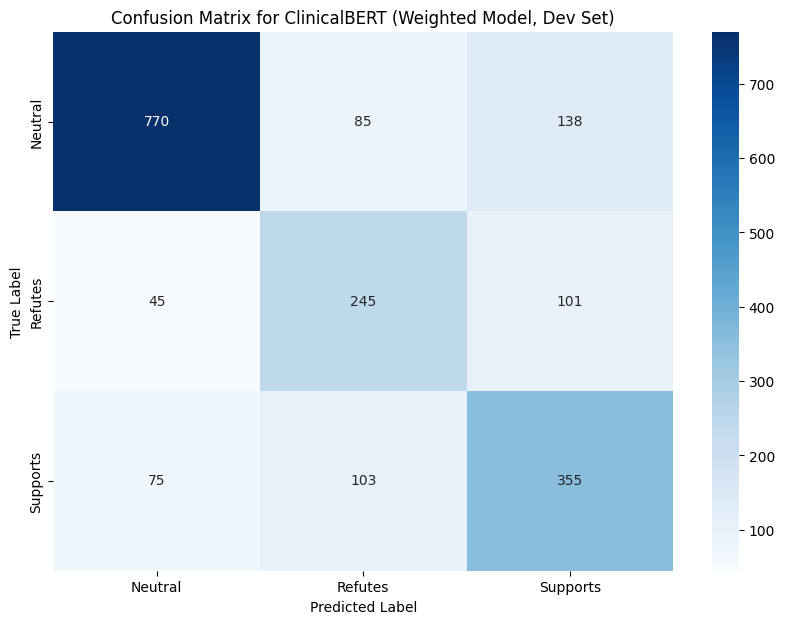

Saving weighted model to ./clinicalbert_weighted...
Model saved. You can now download the './clinicalbert_weighted' folder from the Colab file panel.


In [12]:
# Cell 10: Show Results (Text Report + Confusion Matrix Graph)

if 'all_preds' in locals():
    print("\n--- ClinicalBERT (WEIGHTED) CLASSIFICATION REPORT (Dev Set) ---")

    # --- 1. Print the Text Report ---
    report = classification_report(
        all_true,
        all_preds,
        target_names=LABELS,
        digits=4
    )
    print(report)

    print("--------------------------------------------------")
    print("COMPARE THIS TO YOUR CHAMPION (Weighted BioBERT): ")
    print(f"Your champion BioBERT 'Refutes' F1-score was: 0.6650")
    print("Did ClinicalBERT beat this score?")
    print("--------------------------------------------------")


    # --- 2. Create and Show the Confusion Matrix Graph ---
    print("\nGenerating confusion matrix...")

    cm = confusion_matrix(all_true, all_preds)

    # Plot the heatmap
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm,
        annot=True,     # Show the numbers in each cell
        fmt='d',        # Format the numbers as integers
        cmap='Blues',   # Use a blue color scheme
        xticklabels=LABELS, # Use our label names
        yticklabels=LABELS
    )
    plt.title('Confusion Matrix for ClinicalBERT (Weighted Model, Dev Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show() # This is the command that shows the plot


    # --- 3. Save the Model ---
    if not os.path.exists(SAVE_PATH):
        os.makedirs(SAVE_PATH)

    print(f"Saving weighted model to {SAVE_PATH}...")
    model.save_pretrained(SAVE_PATH)
    tokenizer.save_pretrained(SAVE_PATH)
    print(f"Model saved. You can now download the '{SAVE_PATH}' folder from the Colab file panel.")
else:
    print("Evaluation not run. Please run Cell 9 successfully first.")